In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator
import numpy as np
import seaborn as sns
import pysam
import matplotlib.ticker as mticker
from dimelo import parse_bam, plot_enrichment_profile, plot_reads, load_processed, plot_enrichment, export, plot_read_browser, plot_depth_profile

import config, plotting
from utils import track

In [ ]:
reference_file = config.raw_data_dir / "chm13v2.0.fa"
ctcf_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam"
top_ctcf_bed_file = config.processed_data_dir / "gm12878_ctcf_motif_intersect_chip.top3k.bed"
ctcf_on_target_bed_file = config.processed_data_dir / "gm12878_ctcf.on_target.bed"
ctcf_off_target_bed_file = config.processed_data_dir / "gm12878_ctcf.off_target.bed"
ctcf_output_id = f"{ctcf_bam_file.stem}.{top_ctcf_bed_file.stem}"
# TODO: This file name will likely change; also should this pileup be performed elsewhere?
fiberseq_bam_file = config.processed_data_dir / "GM12878_WGS.retagged.bam"

# TODO: Can I unify across the different bed files so that I don't need as many window sizes?
ctcf_main_figure_window_size = 1000
# NOTE: Match window sizes set in third_party_data.ipynb
ctcf_on_target_window_size = 200
ctcf_off_target_window_size = 1300

# single read browser settings
ctcf_h1_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.h1.new.bam"
ctcf_h2_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.h2.new.bam"
ctcf_peak_bed_gz_file = config.processed_data_dir / "ENCFF797SDL.t2t_chm13v2.sorted.bed.gz"
gm12878_vcf = config.processed_data_dir / "NA12878.chm13v2.vcf.gz"
parse_regions = ["chrX:129_000_000-131_000_000","chrX:37_600_000-37_800_000"]
chrX_full = "chrX:0-248_956_422"
single_read_plot_center = 130_072_000
single_read_plot_window_size = 8000
single_read_plot_palette = {
    "A,0": "#1F77B4",
    "GCH,1": "#2CA02C",
    "WCG,1": "#D62728",
}
single_read_plot_colorscales = {k: ["white", v] for k, v in single_read_plot_palette.items()}

a_only_bam_file = config.processed_data_dir / "20240831_GpC_CpG_crosstalk_demuxed" / "barcode10.bam"

motifs = ["A,0", "GCH,1", "WCG,1"]
mod_prob_thresh = 0.75
smoothing = 25
n_cores = 10

Pileup/extract operations for on-/off-target regions

In [5]:
with track(f"pileup.{ctcf_output_id}", log_path="perf.jsonl"):
    parse_bam.pileup(
        input_file=ctcf_bam_file,
        output_name=f"pileup.{ctcf_output_id}",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=top_ctcf_bed_file,
        motifs=motifs,
        thresh=mod_prob_thresh,
        window_size=ctcf_on_target_window_size + ctcf_off_target_window_size,
        cores=n_cores,
        override_checks=True
    )

with track(f"extract.{ctcf_output_id}", log_path="perf.jsonl"):
    parse_bam.extract(
        input_file=ctcf_bam_file,
        output_name=f"extract.{ctcf_output_id}",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=top_ctcf_bed_file,
        motifs=motifs,
        thresh=None, # No thresholding at extract time
        window_size=ctcf_main_figure_window_size,
        cores=n_cores,
        override_checks=True,
    )

with track(f"extract.{ctcf_output_id}.on_target", log_path="perf.jsonl"):
    parse_bam.extract(
        input_file=ctcf_bam_file,
        output_name=f"extract.{ctcf_output_id}.on_target",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=ctcf_on_target_bed_file,
        motifs=motifs,
        thresh=None, # No thresholding at extract time
        window_size=None,
        cores=n_cores,
        override_checks=True,
    )

with track(f"extract.{ctcf_output_id}.off_target", log_path="perf.jsonl"):
    parse_bam.extract(
        input_file=ctcf_bam_file,
        output_name=f"extract.{ctcf_output_id}.off_target",
        ref_genome=reference_file,
        output_directory=config.processed_data_dir,
        regions=ctcf_off_target_bed_file,
        motifs=motifs,
        thresh=None, # No thresholding at extract time
        window_size=None,
        cores=n_cores,
        override_checks=True,
    )

Please verify that 20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam is actually aligned to chm13v2.0.fa.
Allocating requested 10 cores.
Modification threshold of 0.75 will be treated as coming from range 0-1.


          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in 20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3…

          |    0%

[perf] pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.gm12878_ctcf_motif_intersect_chip.top3k: 95.4s  peak 18.81 GB
Please verify that 20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam is actually aligned to chm13v2.0.fa.
Allocating requested 10 cores.
No valid base modification threshold provided. Raw probs will be saved.


...

          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in 20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3…

          |    0%

          | Transferring 122782 from reads.WCG,1.txt into reads.combined_basemods.h5, new size 385248   0% | 0…

[perf] extract.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.gm12878_ctcf_motif_intersect_chip.top3k.off_target: 1061.1s  peak 22.65 GB


Export operations for genome browser

In [ ]:
# For now, chosing to export chr11 due to the presence of known CTCF features (β-globin, H19–Igf2)
export_region = "chr11:0-135127769"

output_name = f"pileup.{ctcf_bam_file.stem}.browser"
parse_bam.pileup(
    input_file=ctcf_bam_file,
    output_name=output_name,
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions="chr11:0-135127769",
    motifs=motifs,
    thresh=mod_prob_thresh,
    cores=n_cores,
    override_checks=True
)

for motif in motifs:
    export.pileup_to_bigwig(
        bedmethyl_file=config.processed_data_dir / output_name / "pileup.sorted.bed.gz",
        motif=motif,
        bigwig_file=config.processed_data_dir / f"{output_name}_{motif.split(',')[0]}.bigWig",
        ref_genome=reference_file
    )


output_name = f"pileup.{fiberseq_bam_file.stem}.browser"
parse_bam.pileup(
    input_file=fiberseq_bam_file,
    output_name=output_name,
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions="chr11:0-135127769",
    motifs=["A,0"],
    thresh=250,
    cores=n_cores,
    override_checks=True
)

export.pileup_to_bigwig(
    bedmethyl_file=config.processed_data_dir / output_name / "pileup.sorted.bed.gz",
    motif="A,0",
    bigwig_file=config.processed_data_dir / f"{output_name}_A.bigWig",
    ref_genome=reference_file
)

parse_bam.pileup(
    input_file=fiberseq_bam_file,
    output_name=output_name,
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions="chr11:0-135127769",
    motifs=["CG,0"],
    thresh=0.5,
    cores=n_cores,
    override_checks=True
)

export.pileup_to_bigwig(
    bedmethyl_file=config.processed_data_dir / output_name / "pileup.sorted.bed.gz",
    motif="CG,0",
    bigwig_file=config.processed_data_dir / f"{output_name}_CG.bigWig",
    ref_genome=reference_file
)

Pileup and extract operations for haplotype phased single read plot

In [6]:
with track(f"extract.hp1.{'_'.join(parse_regions)}", log_path="perf.jsonl"):
    parse_bam.extract(
        input_file=ctcf_h1_bam_file,
        output_name="hp1_chrX_extract",
        output_directory=config.processed_data_dir,
        ref_genome=reference_file,
        regions=parse_regions,
        motifs=motifs,
    )
with track(f"extract.hp2.{'_'.join(parse_regions)}", log_path="perf.jsonl"):
    parse_bam.extract(
        input_file=ctcf_h2_bam_file,
        output_name="hp2_chrX_extract",
        output_directory=config.processed_data_dir,
        ref_genome=reference_file,
        regions=parse_regions,
        motifs=motifs,
        override_checks=True,
    )
with track(f"pileup.hp1.{'_'.join(parse_regions)}", log_path="perf.jsonl"):
    parse_bam.pileup(
        input_file=ctcf_h1_bam_file,
        output_name="hp1_chrX_pileup",
        output_directory=config.processed_data_dir,
        ref_genome=reference_file,
        regions=parse_regions,
        motifs=motifs,
        thresh=mod_prob_thresh,
    )
with track(f"pileup.hp2.{'_'.join(parse_regions)}", log_path="perf.jsonl"):
    parse_bam.pileup(
        input_file=ctcf_h2_bam_file,
        output_name="hp2_chrX_pileup",
        output_directory=config.processed_data_dir,
        ref_genome=reference_file,
        regions=parse_regions,
        motifs=motifs,
        thresh=mod_prob_thresh,
        override_checks=True,
    )


Do you expect this file to contain these modifications? parse_bam is looking for ['A,0', 'GCH,1', 'WCG,1'] but for ['A', 'C'] found only found [].

Consider passing only the motifs and mod codes (e.g. m,h,a) that you expect to be present in your file. 
You can use modkit adjust-mods --convert <CONVERT> <CONVERT> [OPTIONS] <IN_BAM> <OUT_BAM> to update or consolidate mod codes.
See https://github.com/nanoporetech/modkit/blob/master/book/src/advanced_usage.md
                    
No specified number of cores requested. 24 available on machine, allocating all.
No valid base modification threshold provided. Raw probs will be saved.


          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in 20240923_dimelo_access_background.h1.new.bam   0% | 00:00<?

          |    0%

          | Transferring 2467 from reads.A,0.txt into reads.combined_basemods.h5, new size 2467   0% | 00:00<?

...

[perf] pileup.hp1.chrX:129_000_000-131_000_000_chrX:37_600_000-37_800_000: 13.8s  peak 26.95 GB
Please verify that 20240923_dimelo_access_background.h2.new.bam is actually aligned to chm13v2.0.fa.
No specified number of cores requested. 24 available on machine, allocating all.
Modification threshold of 0.75 will be treated as coming from range 0-1.


          | Step 1: Identify motif locations in chm13v2.0.fa   0% | 00:00

          | Step 2: Parse regions in 20240923_dimelo_access_background.h2.new.bam   0% | 00:00<?

          |    0%

[perf] pileup.hp2.chrX:129_000_000-131_000_000_chrX:37_600_000-37_800_000: 13.6s  peak 26.99 GB


Pileup operations for on/off target supplement with single-signal data

In [ ]:
# parse_bam.pileup(
#     input_file=gc_only_bam_file,
#     output_name=f"pileup.gc_only_ctcf_sites",
#     ref_genome=reference_file,
#     output_directory=config.processed_data_dir,
#     regions=top_ctcf_bed_file,
#     motifs=["GCH,1", "WCG,1"],
#     thresh=mod_prob_thresh,
#     window_size=ctcf_on_target_window_size + ctcf_off_target_window_size,
#     cores=n_cores,
#     override_checks=True
# )

parse_bam.pileup(
    input_file=a_only_bam_file,
    output_name=f"pileup.a_only_ctcf_sites",
    ref_genome=reference_file,
    output_directory=config.processed_data_dir,
    regions=top_ctcf_bed_file,
    motifs=["A,0", "WCG,1"],
    thresh=mod_prob_thresh,
    window_size=ctcf_on_target_window_size + ctcf_off_target_window_size,
    cores=n_cores,
    override_checks=True
)

# Main text figures

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

[perf] plot_enrichment_profile.by_modification.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.gm12878_ctcf_motif_intersect_chip.top3k: 5.9s  peak 4.98 GB


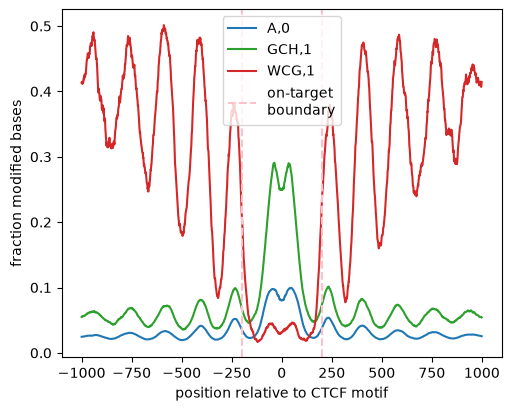

In [3]:
_, ax = plt.subplots(1, 1, figsize=(5, 4), layout="constrained")
with track(f"plot_enrichment_profile.by_modification.{ctcf_output_id}", log_path="perf.jsonl"):
    plot_enrichment_profile.by_modification(
        config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
        regions=top_ctcf_bed_file,
        motifs=motifs,
        window_size=ctcf_main_figure_window_size,
        smooth_window=smoothing,
        palette=plotting.default_palette_map,
        ax=ax
    )
plt.axvline(-ctcf_on_target_window_size, linestyle="--", color="pink", label="on-target\nboundary")
plt.axvline(ctcf_on_target_window_size, linestyle="--", color="pink")
ax.set_xlabel("position relative to CTCF motif")
ax.legend(title="")

plt.savefig(config.figure_dir / "ctcf.plot_enrichment_profile.svg")
plt.show()
plt.close()

[perf] plot_reads.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.gm12878_ctcf_motif_intersect_chip.top3k: 56.8s  peak 3.57 GB


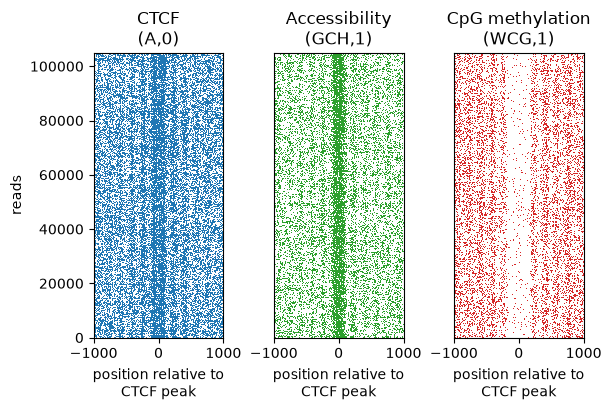

In [9]:
_, axs = plt.subplots(1, 3, figsize=(6, 4), layout="constrained")
titles = ["CTCF", "Accessibility", "CpG methylation"]
with track(f"plot_reads.{ctcf_output_id}", log_path="perf.jsonl"):
    for motif, ax, title in zip(motifs, axs, titles):
        plot_reads.plot_reads(
            mod_file_name=config.processed_data_dir / f"extract.{ctcf_output_id}" / "reads.combined_basemods.h5",
            regions=top_ctcf_bed_file,
            motifs=motif,
            window_size=ctcf_main_figure_window_size,
            regions_5to3prime=False,
            sort_by="shuffle",
            thresh=mod_prob_thresh,
            ax=ax,
            palette=plotting.default_palette_map,
            rasterized=True,
            s=0.015
        )
        ax.set_title(f"{title}\n({motif})")
        ax.set_xlabel("position relative to\nCTCF peak")
        ax.set_ylabel("reads")
        if title != "CTCF":
            ax.yaxis.set_visible(False)
        ax.set_ylim(0,105000)
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
        # sns.move_legend(ax, loc="upper left")

plt.savefig(config.figure_dir / "ctcf.plot_reads.svg")
plt.show()
plt.close()

## Single reads

In [10]:
def plot_genomic_region(variants, peaks, start_pos, end_pos,
                        chromosome="chrX",
                        variant_label="Variant sites",
                        peak_label="CTCF ChIP peaks",
                        figsize=(10, 2)):
    fig, ax = plt.subplots(figsize=figsize)

    # --- Peaks: thicker bars, sitting on top ---
    peak_height = 0.2          # was 0.2 -> nice and thick
    peak_y = 0.50               # bottom edge of the bars
    for peak_start, peak_end in peaks:
        width = peak_end - peak_start
        rect = patches.Rectangle((peak_start, peak_y), width, peak_height,
                                 linewidth=0, facecolor='#1F77B4', zorder=3,
                                 label=peak_label if peak_start == peaks[0][0] else "")
        ax.add_patch(rect)

    # --- Variants: row below the peaks ---
    variant_y = 0.25
    for i, variant_pos in enumerate(variants):
        ax.plot(variant_pos, variant_y, 's', color='purple',
                markersize=5, zorder=4,
                label=variant_label if i == 0 else "")

    ax.set_xlim(start_pos, end_pos)
    ax.set_ylim(0, 1.0)         # tightened so the two rows are centered

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1)
    ax.set_yticks([])

    # --- x ticks unchanged ---
    ax.xaxis.set_major_locator(MultipleLocator(2500))
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x/1e6:.3f}')
    )
    ax.set_xlabel(chromosome + " position", fontsize=11)
    ax.tick_params(axis='x', labelsize=10)

    # --- Legend off-frame (to the right) ---
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
              frameon=False, fontsize=10)

    plt.tight_layout()
    return fig, ax

In [11]:
peaks_tabix = pysam.TabixFile(str(ctcf_peak_bed_gz_file))
variants_tabix = pysam.TabixFile(str(gm12878_vcf))

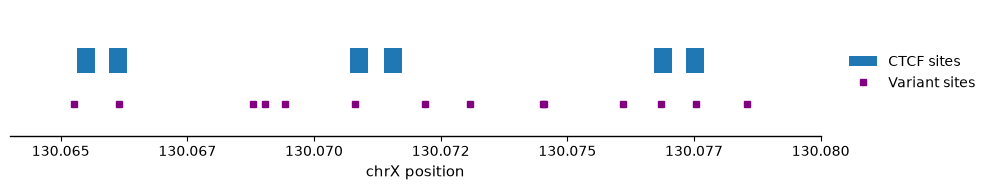

In [19]:
peaks_list = []
for peak_line in peaks_tabix.fetch("chrX", single_read_plot_center-single_read_plot_window_size, single_read_plot_center+single_read_plot_window_size):
    peak_fields = peak_line.strip().split('\t')
    peak_start = int(peak_fields[1])
    peak_end = int(peak_fields[2])
    peaks_list.append((peak_start, peak_end))
variant_pos_list = []
for variant_line in variants_tabix.fetch("chrX", single_read_plot_center-single_read_plot_window_size, single_read_plot_center+single_read_plot_window_size):
    variant_fields = variant_line.strip().split('\t')
    variant_pos = int(variant_fields[1])
    variant_pos_list.append(variant_pos)
fig, ax = plot_genomic_region(
    variants=variant_pos_list,
    peaks=peaks_list,
    start_pos=single_read_plot_center - single_read_plot_window_size,
    end_pos=single_read_plot_center + single_read_plot_window_size,
    chromosome="chrX",
    variant_label="Variant sites",
    peak_label="CTCF sites",
    figsize=(10, 2)
)
fig.savefig(config.figure_dir / f"chrX_{single_read_plot_center}.svg", format="svg", bbox_inches='tight', dpi=300)

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

Loading data:   0%|          | 0/1 [00:00<?, ?it/s]

[perf] plot_enrichment_profile.by_modification.hp1_hp2_chrX: 5.3s  peak 46.54 GB


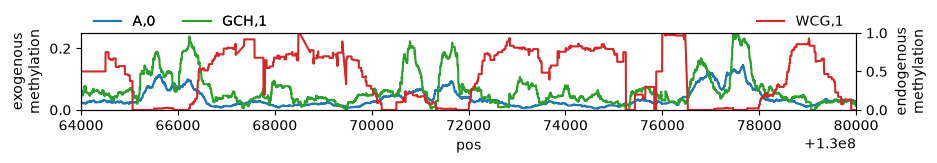

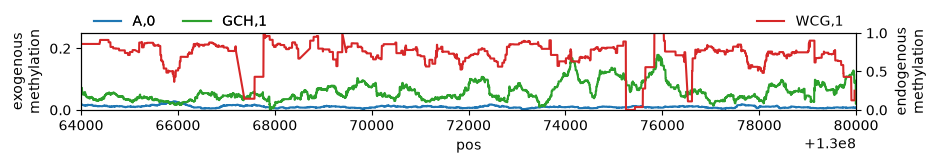

In [12]:
hp1_fig, hp1_ax1 = plt.subplots(figsize=(10,1))
hp2_fig, hp2_ax1 = plt.subplots(figsize=(10,1))
hp1_ax2 = hp1_ax1.twinx()
hp2_ax2 = hp2_ax1.twinx()
hp1_ax1.set_xlim(single_read_plot_center - single_read_plot_window_size, single_read_plot_center + single_read_plot_window_size)
hp2_ax1.set_xlim(single_read_plot_center - single_read_plot_window_size, single_read_plot_center + single_read_plot_window_size)
with track(f"plot_enrichment_profile.by_modification.hp1_hp2_chrX", log_path="perf.jsonl"):
    for profile_motifs, ylim, hp1_ax, hp2_ax in (
        (["A,0","GCH,1"], (0,0.25), hp1_ax1, hp2_ax1),
        (["WCG,1"], (0,1.0), hp1_ax2, hp2_ax2),
    ):
        smooth_window = 400
        plot_enrichment_profile.by_modification(
            mod_file_name=config.processed_data_dir / "hp1_chrX_pileup" / "pileup.sorted.bed.gz",
            regions = f"chrX:{single_read_plot_center - single_read_plot_window_size // 2}-{single_read_plot_center + single_read_plot_window_size // 2}",
            motifs=profile_motifs,
            window_size=single_read_plot_window_size,
            relative=False,
            smooth_window=smooth_window,
            palette=single_read_plot_palette,
            ax=hp1_ax,
        )
        hp1_ax.set_ylim(*ylim)
        hp1_ax.legend().remove()
        plot_enrichment_profile.by_modification(
            mod_file_name=config.processed_data_dir / "hp2_chrX_pileup" / "pileup.sorted.bed.gz",
            regions=f"chrX:{single_read_plot_center - single_read_plot_window_size // 2}-{single_read_plot_center + single_read_plot_window_size // 2}",
            motifs=profile_motifs,
            window_size=single_read_plot_window_size,
            relative=False,
            smooth_window=smooth_window,
            palette=single_read_plot_palette,
            ax=hp2_ax,
        )
        hp2_ax.set_ylim(*ylim)
        hp2_ax.legend().remove()
    hp1_ax1.set_ylabel("exogenous\nmethylation")
    hp1_ax2.set_ylabel("endogenous\nmethylation")
    hp2_ax1.set_ylabel("exogenous\nmethylation")
    hp2_ax2.set_ylabel("endogenous\nmethylation")

    # Get handles and labels from both axes
    handles1, labels1 = hp1_ax1.get_legend_handles_labels()
    handles2, labels2 = hp1_ax2.get_legend_handles_labels()
    # Create left legend (A,0 and GCH,1)
    leg_left = hp1_ax1.legend(
        handles1, labels1,
        loc='upper left',
        bbox_to_anchor=(0, 1.4),
        ncol=2,
        frameon=False
    )
    # Create right legend (WCG,1) and add back the left legend
    leg_right = hp1_ax2.legend(
        handles2, labels2,
        loc='upper right',
        bbox_to_anchor=(1, 1.4),
        ncol=1,
        frameon=False
    )
    # Important: add the left legend back since creating the right one removes it
    hp1_ax1.add_artist(leg_left)
    # Same for the second subplot
    handles1, labels1 = hp2_ax1.get_legend_handles_labels()
    handles2, labels2 = hp2_ax2.get_legend_handles_labels()

    leg_left2 = hp2_ax1.legend(
        handles1, labels1,
        loc='upper left',
        bbox_to_anchor=(0, 1.4),
        ncol=2,
        frameon=False
    )
    leg_right2 = hp2_ax2.legend(
        handles2, labels2,
        loc='upper right',
        bbox_to_anchor=(1, 1.4),
        ncol=1,
        frameon=False
    )

    hp2_ax1.add_artist(leg_left2)

hp1_fig.savefig(config.figure_dir / f"hp1_chrX_{single_read_plot_center}_enrichment_profile_smooth{smooth_window}.new.svg", format="svg", bbox_inches='tight', dpi=300)
hp2_fig.savefig(config.figure_dir / f"hp2_chrX_{single_read_plot_center}_enrichment_profile_smooth{smooth_window}.new.svg", format="svg", bbox_inches='tight', dpi=300)

In [13]:
plot_width = 800
# TODO: Does the order of these motifs matter, or can I just reference the top-level motif list?
browser_motifs = ["WCG,1","A,0","GCH,1"]
browser_title = "Hia5 CTCF + M.CviPI accessibility"

with track(f"plot_read_browser.{ctcf_output_id}.hp1_hp2_chrX", log_path="perf.jsonl"):
    for extract_file, haplotype in [
        (config.processed_data_dir / "hp1_chrX_extract" / "reads.combined_basemods.h5", f" hp1"),
        (config.processed_data_dir / "hp2_chrX_extract" / "reads.combined_basemods.h5", f" hp2")
    ]:
        sort_by = "collapse"
        fig = plot_read_browser.plot_read_browser(
            mod_file_name = extract_file,
            region = f'chrX:{single_read_plot_center-single_read_plot_window_size}-{single_read_plot_center+single_read_plot_window_size}',
            motifs = browser_motifs,
            thresh = 0.75,
            sort_by = sort_by,
            colorscales = single_read_plot_colorscales
        )
        fig.update_layout(
            width=plot_width,# these values are in pixels
            height=300,    
            title={
                'text': browser_title + haplotype,
                'x': 0.5,
                'xanchor': 'center',
                'y': 0.75,  # Adjust the vertical position of the title
                'yanchor': 'top',
                'pad': {'b': 10} 
            },
            xaxis_title='chr1 coordinate, t2t v2.0',
            yaxis_title='reads',
            font=dict(color='black')
        )
        fig.write_image(config.figure_dir / f"{haplotype.strip().replace(' ','_')}_chrX_{single_read_plot_center}_read_browser_width{plot_width}px.new.svg", format="svg", scale=2)
        fig.show()

[perf] plot_read_browser.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.gm12878_ctcf_motif_intersect_chip.top3k.hp1_hp2_chrX: 3.4s  peak 4.36 GB


# Supplemental Figures

In [14]:
rng = np.random.default_rng()
mod_event_sample_size = 200000  # subsetting mod events to save on time and memory

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

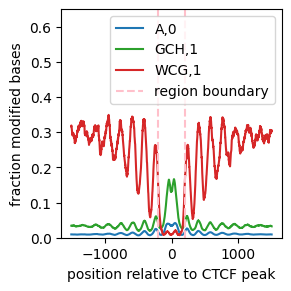

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(2.8, 2.8), layout="constrained")
ax = plot_enrichment_profile.by_modification(
    config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
    regions=top_ctcf_bed_file,
    motifs=motifs,
    window_size=ctcf_on_target_window_size + ctcf_off_target_window_size,
    smooth_window=smoothing,
    palette=plotting.default_palette_map
)
plt.axvline(-ctcf_on_target_window_size, linestyle="--", color="pink", label="region boundary")
plt.axvline(ctcf_on_target_window_size, linestyle="--", color="pink")
# recreate legend to both add new entry and restrict location to the bottom right quadrant
ax.set_ylim(0, 0.65)
ax.legend(
    loc='best',
    # bbox_to_anchor=(0.5, 0., 0.5, 0.5)
)
ax.set_xlabel("position relative to CTCF peak")
plt.savefig(config.figure_dir / "ctcf.plot_enrichment_profile.full.svg")
plt.show()
plt.close()

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/6000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/6000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/3000 [00:00<?, ?it/s]

Loading data:   0%|          | 0/6000 [00:00<?, ?it/s]

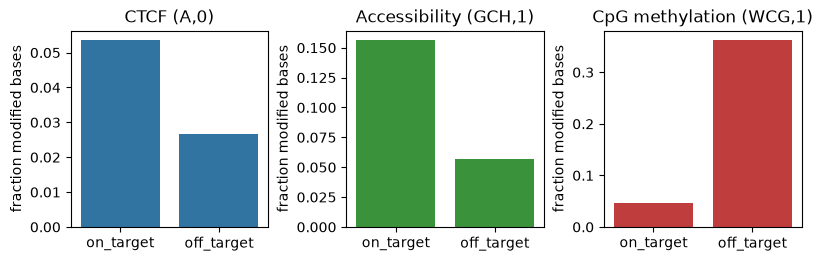

[perf] plot_enrichment.by_regions.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.gm12878_ctcf_motif_intersect_chip.top3k: 20.0s  peak 5.35 GB


In [4]:
fig, axes = plt.subplots(1, 3, layout="constrained", figsize=(8, 2.5))

with track(f"plot_enrichment.by_regions.{ctcf_output_id}", log_path="perf.jsonl"):

    sample_names = ["on_target", "off_target"]
    titles = ["CTCF", "Accessibility", "CpG methylation"]
    for motif, ax, title in zip(motifs, axes, titles):
        plot_enrichment.by_regions(
            mod_file_name=config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
            regions_list=[ctcf_on_target_bed_file, ctcf_off_target_bed_file],
            motif=motif,
            sample_names=sample_names,
            palette = {sample_name: plotting.default_palette_map[motif] for sample_name in sample_names},
            ax=ax
        )
        ax.set_title(f"{title} ({motif})")

    plt.savefig(config.figure_dir / "ctcf.plot_enrichment.svg")
    plt.show()
    plt.close()

In [16]:
with track(f"read_vectors_from_hdf5.{ctcf_output_id}", log_path="perf.jsonl"):
    on_target_motif_mod_vector_dict = {}
    file_path = config.processed_data_dir / f"extract.{ctcf_output_id}.on_target" / "reads.combined_basemods.h5"
    for motif in motifs:
        read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
            file=file_path,
            motifs=[motif],
            regions=ctcf_on_target_bed_file,
            single_strand=False,
            sort_by="shuffle",
            calculate_mod_fractions=False,
        )
        mod_vector_index = entry_labels.index("mod_vector")
        val_vector_index = entry_labels.index("val_vector")
        mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
        # TODO: Does it matter if I sample without replacement here?
        on_target_motif_mod_vector_dict[motif] = rng.choice(mod_vector, mod_event_sample_size, replace=False)
    off_target_motif_mod_vector_dict = {}
    file_path = config.processed_data_dir / f"extract.{ctcf_output_id}.off_target" / "reads.combined_basemods.h5"
    for motif in motifs:
        read_tuples, entry_labels, _ = load_processed.read_vectors_from_hdf5(
            file=file_path,
            motifs=[motif],
            regions=ctcf_off_target_bed_file,
            single_strand=False,
            sort_by="shuffle",
            calculate_mod_fractions=False,
        )
        mod_vector_index = entry_labels.index("mod_vector")
        val_vector_index = entry_labels.index("val_vector")
        mod_vector = np.concatenate([read_tuple[mod_vector_index][read_tuple[val_vector_index] == 1] for read_tuple in read_tuples])
        # TODO: Does it matter if I sample without replacement here?
        off_target_motif_mod_vector_dict[motif] = rng.choice(mod_vector, mod_event_sample_size, replace=False)

[perf] read_vectors_from_hdf5.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.gm12878_ctcf_motif_intersect_chip.top3k: 148.4s  peak 11.54 GB


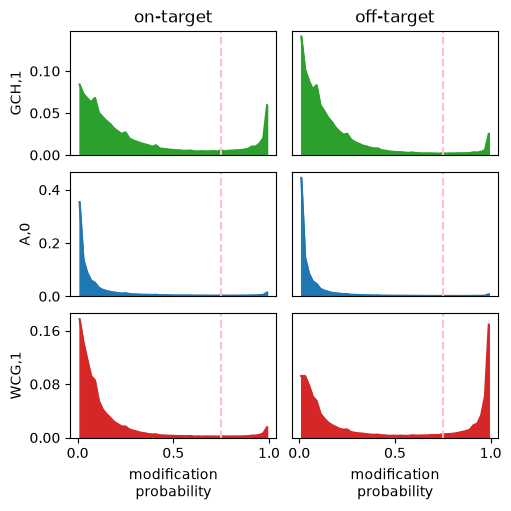

In [19]:
motifs = ["GCH,1", "A,0", "WCG,1"]
targets = ["on-target", "off-target"]
target_keys = ["on", "off"]
target_dicts = [on_target_motif_mod_vector_dict, off_target_motif_mod_vector_dict]

# shared PMF grid over the modification-probability range [0, 1]
pmf_bins = np.linspace(0, 1, 51)
pmf_centers = 0.5 * (pmf_bins[:-1] + pmf_bins[1:])

def to_pmf(vec):
    counts, _ = np.histogram(vec, bins=pmf_bins)
    total = counts.sum()
    return counts / total if total else counts

# rows = motifs, columns = on-target | off-target
mosaic = [[f"{motif}:on", f"{motif}:off"] for motif in motifs]
fig, axs_dict = plt.subplot_mosaic(mosaic, layout="constrained", figsize=(5, 5))

for motif_idx, motif in enumerate(motifs):
    color = plotting.default_palette_map[motif]
    vecs = [target_dicts[t][motif] for t in range(2)]
    pmfs = [to_pmf(v) for v in vecs]

    for i, target in enumerate(targets):
        ax = axs_dict[f"{motif}:{target_keys[i]}"]
        sns.lineplot(x=pmf_centers, y=pmfs[i], ax=ax, color=color)
        ax.fill_between(pmf_centers, pmfs[i], color=color)
        if motif_idx == 0:
            ax.set_title(target)
        if motif_idx != len(motifs) - 1:
            ax.set_xticks([])
        else:
            ax.set_xlabel("modification\nprobability")
        if i == 0:
            ax.set_ylabel(motif)
            ax.yaxis.set_major_locator(mticker.MaxNLocator(3))
        else:
            ax.set_yticks([])
        ax.axvline(mod_prob_thresh, linestyle="--", color="pink")

    # Shared y limits across the on/off pair
    row_axes = [axs_dict[f"{motif}:{k}"] for k in target_keys]
    row_ymax = max(pmfs[0].max(), pmfs[1].max())
    for ax in row_axes:
        ax.set_ylim(0, row_ymax * 1.05)

plt.savefig(config.figure_dir / "ctcf.mod_probs.on_vs_off_target.svg", bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
fig, axes = plt.subplots(2, 3, layout="constrained", figsize=(8, 5))

sample_names = ["on_target", "off_target"]
titles = ["CTCF", "Accessibility", "CpG methylation"]

for motif, ax in zip(["A,0", "WCG,1"], [axes[0][0], axes[0][2]]):
    plot_enrichment.by_regions(
        mod_file_name=config.processed_data_dir / f"pileup.a_only_ctcf_sites" / "pileup.sorted.bed.gz",
        regions_list=[ctcf_on_target_bed_file, ctcf_off_target_bed_file],
        motif=motif,
        sample_names=sample_names,
        palette = {sample_name: plotting.default_palette_map[motif] for sample_name in sample_names},
        ax=ax
    )

for motif, ax in zip(motifs, axes[1]):
    plot_enrichment.by_regions(
        mod_file_name=config.processed_data_dir / f"pileup.{ctcf_output_id}" / "pileup.sorted.bed.gz",
        regions_list=[ctcf_on_target_bed_file, ctcf_off_target_bed_file],
        motif=motif,
        sample_names=sample_names,
        palette = {sample_name: plotting.default_palette_map[motif] for sample_name in sample_names},
        ax=ax
    )

for motif, ax, title in zip(motifs, axes[0], titles):
    ax.set_title(f"{title}\n({motif})")

# for motif, ax in zip(["GCH,1", "WCG,1"], [axes[2][1], axes[2][2]]):
#     plot_enrichment.by_regions(
#         mod_file_name=config.processed_data_dir / f"pileup.gc_only_ctcf_sites" / "pileup.sorted.bed.gz",
#         regions_list=[ctcf_on_target_bed_file, ctcf_off_target_bed_file],
#         motif=motif,
#         sample_names=sample_names,
#         palette = {sample_name: plotting.default_palette_map[motif] for sample_name in sample_names},
#         ax=ax
#     )
#     ax.set_title(f"{title} ({motif})")

plt.savefig(config.figure_dir / "ctcf.compare_to_DiMeLo.svg")
plt.show()
plt.close()